In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("/content/Sample - Superstore.csv", encoding='ISO-8859-1')


df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days


df.drop(columns=[
    'Row ID', 'Order ID', 'Customer ID', 'Customer Name',
    'Product ID', 'Product Name', 'Postal Code',
    'Order Date', 'Ship Date'
], inplace=True)


X = df.drop("Profit", axis=1)
y = df["Profit"]


categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


numerical_transformer = SimpleImputer(strategy='mean')
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)


Mean Squared Error (MSE): 52055.43653625892
R² Score: -0.0736372385680899


      Actual Profit  Predicted Profit
3125        21.1428         -1.820790
1441        11.4600         12.417883
4510        17.1580         13.409545
39         -15.1470        -42.201197
4509        -6.4233         -7.765567
1599         8.6744         13.356197
7363       -73.7061        -72.659589
9951         8.6900          8.461118
500        -15.0800        -14.975641
4847        17.9080          6.748020


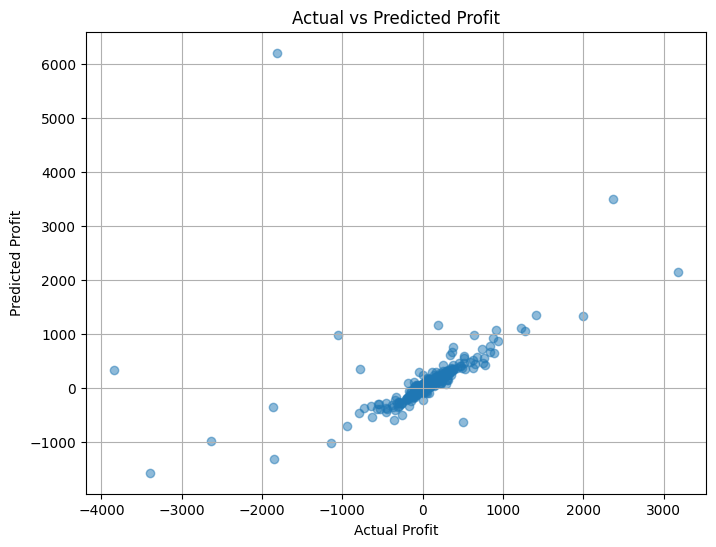

In [3]:

results = pd.DataFrame({
    'Actual Profit': y_test,
    'Predicted Profit': y_pred
})


print(results.head(10))


results.to_csv("model_predictions.csv", index=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.grid(True)
plt.show()
